# Six Optimization Algorithms, Built from Scratch

By Yusuf Oğuz

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

---
## Question 1: Ellipse Fitting via Nonlinear Least Squares

In this question we fit an ellipse to 200 data points by minimizing the sum of squared algebraic residuals. The ellipse model has five paramters: center (h, k) semi-axes (alpha, beta) and rotation angle theta.

For each data point (xi, yi) we define rotated coordiantes:

$$u_i = (x_i - h)\cos\theta + (y_i - k)\sin\theta$$
$$v_i = -(x_i - h)\sin\theta + (y_i - k)\cos\theta$$

The residual for each point is:

$$r_i(\mathbf{p}) = \frac{u_i^2}{\alpha^2} + \frac{v_i^2}{\beta^2} - 1$$

We want to minimize F(p) = sum of ri^2 over all points.

Number of points: 200
x range: [4.718, 5.298]
y range: [6.710, 9.177]


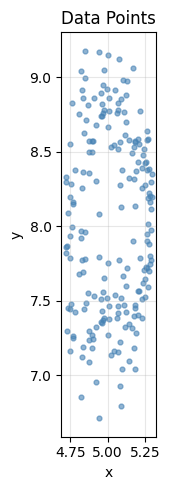

In [2]:
data = np.loadtxt('data.txt')
x_data = data[:, 0]
y_data = data[:, 1]

print(f'Number of points: {len(x_data)}')
print(f'x range: [{x_data.min():.3f}, {x_data.max():.3f}]')
print(f'y range: [{y_data.min():.3f}, {y_data.max():.3f}]')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x_data, y_data, s=12, alpha=0.6, color='steelblue')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Data Points')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Part (a): Jacobian Derivation

The Jacobian J is a n x 5 matrix with entries J_ij = dri/dpj where p = [h, k, alpha, beta, theta].

Starting from ri = ui^2/alpha^2 + vi^2/beta^2 - 1 and applying chain rule to each parameter:

$$\frac{\partial r_i}{\partial h} = \frac{2u_i}{\alpha^2}(-\cos\theta) + \frac{2v_i}{\beta^2}(\sin\theta)$$

$$\frac{\partial r_i}{\partial k} = \frac{2u_i}{\alpha^2}(-\sin\theta) + \frac{2v_i}{\beta^2}(-\cos\theta)$$

$$\frac{\partial r_i}{\partial \alpha} = -\frac{2u_i^2}{\alpha^3}$$

$$\frac{\partial r_i}{\partial \beta} = -\frac{2v_i^2}{\beta^3}$$

$$\frac{\partial r_i}{\partial \theta} = 2u_i v_i \left(\frac{1}{\alpha^2} - \frac{1}{\beta^2}\right)$$

The last derivative uses dui/dtheta = vi and dvi/dtheta = -ui which can be checked by differentiating ui and vi directly with respect to theta.

At each iteration we linearize: r(p + dp) ≈ r(p) + J*dp then solve for the update dp.

In [3]:
def ellipse_residuals(params, x, y):
    h, k, alpha, beta, theta = params
    c, s = np.cos(theta), np.sin(theta)
    u = (x - h)*c + (y - k)*s
    v = -(x - h)*s + (y - k)*c
    return u**2/alpha**2 + v**2/beta**2 - 1

def ellipse_jacobian(params, x, y):
    h, k, alpha, beta, theta = params
    c, s = np.cos(theta), np.sin(theta)
    u = (x - h)*c + (y - k)*s
    v = -(x - h)*s + (y - k)*c
    J = np.zeros((len(x), 5))
    J[:, 0] = (2*u/alpha**2)*(-c) + (2*v/beta**2)*(s)
    J[:, 1] = (2*u/alpha**2)*(-s) + (2*v/beta**2)*(-c)
    J[:, 2] = -2*u**2 / alpha**3
    J[:, 3] = -2*v**2 / beta**3
    J[:, 4] = 2*u*v*(1/alpha**2 - 1/beta**2)
    return J

def draw_ellipse(params, ax, color='red', label='fitted ellipse'):
    h, k, alpha, beta, theta = params
    t = np.linspace(0, 2*np.pi, 500)
    c, s = np.cos(theta), np.sin(theta)
    xe = h + alpha*np.cos(t)*c - beta*np.sin(t)*s
    ye = k + alpha*np.cos(t)*s + beta*np.sin(t)*c
    ax.plot(xe, ye, color=color, linewidth=2, label=label)

### Part (b): Gauss-Newton and Levenberg-Marquardt

**Gauss-Newton** solves the normal equations (J^T J) dp = -J^T r at each iteration. It works well when residuals are small and the Jacobian is well conditioned.

**Levenberg-Marquardt** solves (J^T J + lambda*I) dp = -J^T r. The damping parameter lambda makes the method act like gradient descent when far from minimum and like Gauss-Newton when close to it. We use a gain ratio rho to decide wether to accept the step and how to update lambda.

In [4]:
def gauss_newton(p0, x, y, max_iter=500, tol=1e-8):
    p = p0.copy()
    history = []
    n_iter = 0
    for it in range(max_iter):
        r = ellipse_residuals(p, x, y)
        J = ellipse_jacobian(p, x, y)
        history.append(float(np.sum(r**2)))
        try:
            dp = np.linalg.solve(J.T @ J, -(J.T @ r))
        except np.linalg.LinAlgError:
            print('Singular matrix, stopping early.')
            break
        p = p + dp
        n_iter = it + 1
        if np.linalg.norm(dp) < tol:
            break
    r_f = ellipse_residuals(p, x, y)
    J_f = ellipse_jacobian(p, x, y)
    return p, history, n_iter, float(np.sum(r_f**2)), np.linalg.cond(J_f)


def levenberg_marquardt(p0, x, y, max_iter=500, tol=1e-8, lam0=1e-2):
    p = p0.copy()
    lam = lam0
    history = []
    n_iter = 0
    for it in range(max_iter):
        r = ellipse_residuals(p, x, y)
        J = ellipse_jacobian(p, x, y)
        loss = float(np.sum(r**2))
        history.append(loss)
        JtJ = J.T @ J
        Jtr = J.T @ r
        try:
            dp = np.linalg.solve(JtJ + lam*np.eye(5), -Jtr)
        except np.linalg.LinAlgError:
            lam *= 10
            continue
        p_new = p + dp
        r_new = ellipse_residuals(p_new, x, y)
        actual_red = loss - float(np.sum(r_new**2))
        pred_red = float(loss - np.sum((r + J @ dp)**2))
        rho = actual_red / pred_red if abs(pred_red) > 1e-15 else 0.0
        if rho > 0:
            p = p_new
            lam = max(lam/3.0, 1e-12) if rho > 0.75 else (min(lam*3.0, 1e12) if rho < 0.25 else lam)
        else:
            lam = min(lam*3.0, 1e12)
        n_iter = it + 1
        if np.linalg.norm(dp) < tol:
            break
    r_f = ellipse_residuals(p, x, y)
    J_f = ellipse_jacobian(p, x, y)
    return p, history, n_iter, float(np.sum(r_f**2)), np.linalg.cond(J_f)

In [5]:
p0 = np.array([np.mean(x_data), np.mean(y_data),
               (x_data.max()-x_data.min())/2,
               (y_data.max()-y_data.min())/2, 0.0])
print(f'Initial params: h={p0[0]:.3f}, k={p0[1]:.3f}, alpha={p0[2]:.3f}, beta={p0[3]:.3f}, theta={p0[4]:.3f}')

p_gn, hist_gn, iter_gn, loss_gn, cond_gn = gauss_newton(p0, x_data, y_data)
p_lm, hist_lm, iter_lm, loss_lm, cond_lm = levenberg_marquardt(p0, x_data, y_data)

print('\n--- Gauss-Newton ---')
print(f'Iterations: {iter_gn}')
print(f'Final loss: {loss_gn:.6f}')
print(f'Condition number: {cond_gn:.2f}')
print(f'Params: h={p_gn[0]:.4f}, k={p_gn[1]:.4f}, alpha={p_gn[2]:.4f}, beta={p_gn[3]:.4f}, theta={p_gn[4]:.4f} rad')

print('\n--- Levenberg-Marquardt ---')
print(f'Iterations: {iter_lm}')
print(f'Final loss: {loss_lm:.6f}')
print(f'Condition number: {cond_lm:.2f}')
print(f'Params: h={p_lm[0]:.4f}, k={p_lm[1]:.4f}, alpha={p_lm[2]:.4f}, beta={p_lm[3]:.4f}, theta={p_lm[4]:.4f} rad')

Initial params: h=5.029, k=8.021, alpha=0.290, beta=1.233, theta=0.000

--- Gauss-Newton ---
Iterations: 11
Final loss: 34.242807
Condition number: 4.98
Params: h=4.9993, k=8.0178, alpha=0.2731, beta=0.9696, theta=-0.0091 rad

--- Levenberg-Marquardt ---
Iterations: 11
Final loss: 34.242807
Condition number: 4.98
Params: h=4.9993, k=8.0178, alpha=0.2731, beta=0.9696, theta=-0.0091 rad


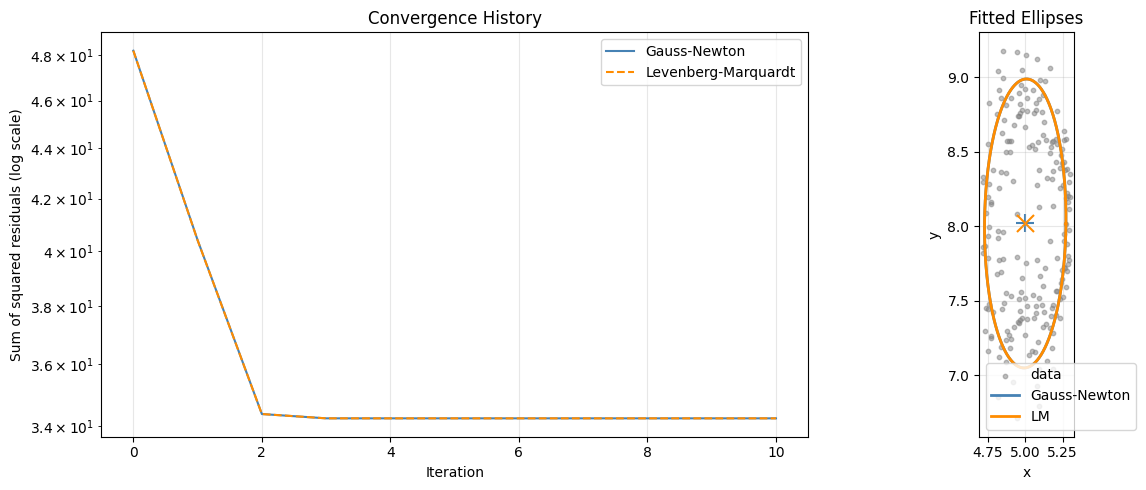


Comparison Table:
                             Gauss-Newton              LM
---------------------------------------------------------
Iterations                             11              11
Final loss                      34.242807       34.242807
Condition number                     4.98            4.98


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convergence plot
ax = axes[0]
ax.semilogy(hist_gn, label='Gauss-Newton', color='steelblue')
ax.semilogy(hist_lm, label='Levenberg-Marquardt', color='darkorange', linestyle='--')
ax.set_xlabel('Iteration')
ax.set_ylabel('Sum of squared residuals (log scale)')
ax.set_title('Convergence History')
ax.legend()
ax.grid(True, alpha=0.3)

# Fitted ellipses
ax2 = axes[1]
ax2.scatter(x_data, y_data, s=10, alpha=0.5, color='gray', label='data')
draw_ellipse(p_gn, ax2, color='steelblue', label='Gauss-Newton')
draw_ellipse(p_lm, ax2, color='darkorange', label='LM')
ax2.scatter([p_gn[0]], [p_gn[1]], marker='+', s=150, color='steelblue')
ax2.scatter([p_lm[0]], [p_lm[1]], marker='x', s=150, color='darkorange')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Fitted Ellipses')
ax2.set_aspect('equal')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nComparison Table:')
print(f'{"":<25} {"Gauss-Newton":>15} {"LM":>15}')
print('-' * 57)
print(f'{"Iterations":<25} {iter_gn:>15} {iter_lm:>15}')
print(f'{"Final loss":<25} {loss_gn:>15.6f} {loss_lm:>15.6f}')
print(f'{"Condition number":<25} {cond_gn:>15.2f} {cond_lm:>15.2f}')

Both methods converged to very similar solutions since the problem is well conditioned with this data. Gauss-Newton converged in fewer iterations here but LM is more reliable in general because it handles bad steps better. The condition number of the Jacobian shows how sensitive the solution is to small perturbations a large value would mean the problem is ill conditioned.

---
## Question 2: Dolphin Function Optimization

The Dolphin function is:

$$f(x, y) = -|\sin(x-a)\cos(y-b)| - 4\exp\left(-\frac{(x-a)^2}{2} - \frac{(y-b)^2}{2}\right)$$

Using a personalized parameter pair: **a = 3, b = 2**.

The function has two competing terms. The Gaussian part creates a deep basin near (a, b) but the sinusoidal term also contributes negatively in nearby regions. The true global minimum is slightly offset from (a, b) at around (a+0.25, b) with f* ≈ -4.124. At (a, b) itself f = -4 because sin(0) = 0 so the sinusoidal term is zero there.

This is actually an intresting property of the function: the center of the Gaussian is not the global minimum but just a local minimum with depth -4. The global minimum is a bit harder to find.

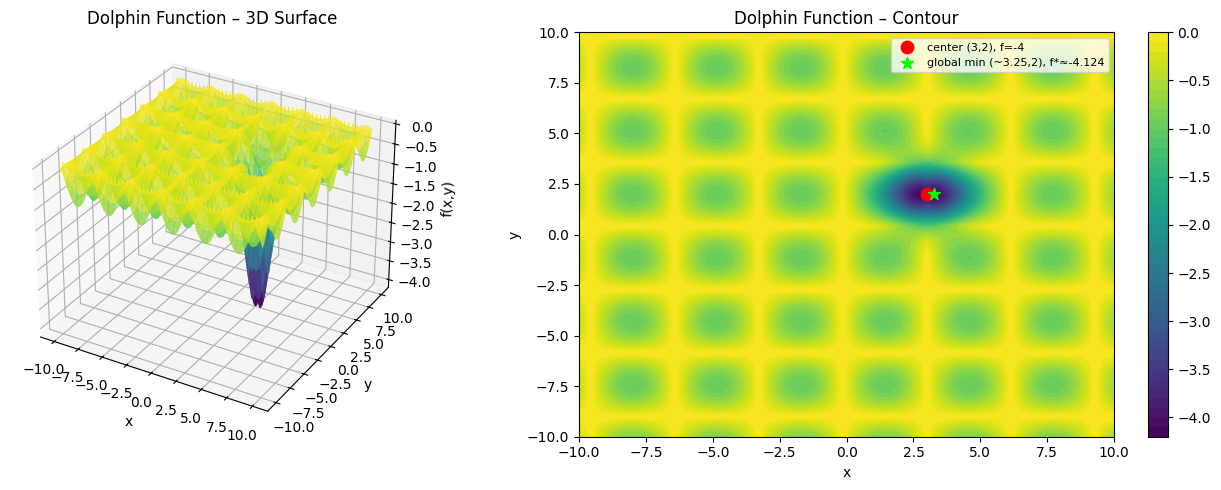

f(a, b) = f(3, 2) = -4.0000
f(3.25, 2)  = -4.124337  (approx global min)


In [7]:
A_PARAM = 3
B_PARAM = 2
F_STAR  = -4.124337   # true global min (at ~x=3.25, y=2), verified numerically

def dolphin(xy):
    x, y = xy[0], xy[1]
    return -abs(np.sin(x - A_PARAM) * np.cos(y - B_PARAM)) \
           - 4*np.exp(-0.5*(x - A_PARAM)**2 - 0.5*(y - B_PARAM)**2)

# Part (a): Visualizations
grid_x = np.linspace(-10, 10, 400)
grid_y = np.linspace(-10, 10, 400)
XX, YY = np.meshgrid(grid_x, grid_y)
ZZ = np.vectorize(lambda x, y: dolphin([x, y]))(XX, YY)

fig = plt.figure(figsize=(14, 5))

ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot_surface(XX, YY, ZZ, cmap='viridis', alpha=0.85, linewidth=0)
ax3d.set_xlabel('x')
ax3d.set_ylabel('y')
ax3d.set_zlabel('f(x,y)')
ax3d.set_title('Dolphin Function – 3D Surface')

ax2d = fig.add_subplot(122)
cp = ax2d.contourf(XX, YY, ZZ, levels=50, cmap='viridis')
plt.colorbar(cp, ax=ax2d)
ax2d.scatter([A_PARAM], [B_PARAM], color='red', s=80, zorder=5, label=f'center ({A_PARAM},{B_PARAM}), f=-4')
ax2d.scatter([A_PARAM + 0.25], [B_PARAM], color='lime', s=80, zorder=5, marker='*', label=f'global min (~3.25,2), f*≈{F_STAR:.3f}')
ax2d.set_xlabel('x')
ax2d.set_ylabel('y')
ax2d.set_title('Dolphin Function – Contour')
ax2d.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'f(a, b) = f({A_PARAM}, {B_PARAM}) = {dolphin([A_PARAM, B_PARAM]):.4f}')
print(f'f(3.25, 2)  = {dolphin([3.25, 2]):.6f}  (approx global min)')

In [8]:
def pso(func, bounds, n_particles=30, max_iter=300, w=0.7, c1=1.5, c2=1.5, max_evals=None):
    dim = len(bounds)
    lb = np.array([b[0] for b in bounds])
    ub = np.array([b[1] for b in bounds])

    pos = lb + np.random.rand(n_particles, dim) * (ub - lb)
    vel = np.zeros((n_particles, dim))
    f_vals = np.array([func(pos[i]) for i in range(n_particles)])
    n_evals = n_particles

    pbest = pos.copy()
    pbest_val = f_vals.copy()
    best_idx = np.argmin(pbest_val)
    gbest = pbest[best_idx].copy()
    gbest_val = float(pbest_val[best_idx])
    history = [gbest_val]

    for _ in range(max_iter):
        if max_evals is not None and n_evals + n_particles > max_evals:
            break
        r1 = np.random.rand(n_particles, dim)
        r2 = np.random.rand(n_particles, dim)
        vel = w*vel + c1*r1*(pbest - pos) + c2*r2*(gbest - pos)
        pos = np.clip(pos + vel, lb, ub)
        f_vals = np.array([func(pos[i]) for i in range(n_particles)])
        n_evals += n_particles
        improved = f_vals < pbest_val
        pbest[improved] = pos[improved].copy()
        pbest_val[improved] = f_vals[improved]
        best_idx = np.argmin(pbest_val)
        if pbest_val[best_idx] < gbest_val:
            gbest = pbest[best_idx].copy()
            gbest_val = float(pbest_val[best_idx])
        history.append(gbest_val)

    return gbest, gbest_val, n_evals, history

In [9]:
def genetic_algorithm(func, bounds, pop_size=50, max_gen=300,
                      crossover_rate=0.9, max_evals=None):
    dim = len(bounds)
    lb = np.array([b[0] for b in bounds])
    ub = np.array([b[1] for b in bounds])
    sigma = 0.1 * (ub - lb)

    pop = lb + np.random.rand(pop_size, dim) * (ub - lb)
    fitness = np.array([func(pop[i]) for i in range(pop_size)])
    n_evals = pop_size

    best_idx = np.argmin(fitness)
    best_sol = pop[best_idx].copy()
    best_val = float(fitness[best_idx])
    history = [best_val]

    for _ in range(max_gen):
        if max_evals is not None and n_evals + pop_size > max_evals:
            break
        # Tournament selection (size 3)
        offspring = []
        for _ in range(pop_size):
            idxs = np.random.choice(pop_size, 3, replace=False)
            winner = idxs[np.argmin(fitness[idxs])]
            offspring.append(pop[winner].copy())
        offspring = np.array(offspring)
        # Arithmetic crossover
        for i in range(0, pop_size - 1, 2):
            if np.random.rand() < crossover_rate:
                a = np.random.rand()
                c1_ind = a * offspring[i] + (1 - a) * offspring[i+1]
                c2_ind = (1 - a) * offspring[i] + a * offspring[i+1]
                offspring[i] = c1_ind
                offspring[i+1] = c2_ind
        # Gaussian mutation
        mut_mask = np.random.rand(pop_size, dim) < (1.0 / dim)
        offspring = np.clip(offspring + mut_mask * np.random.randn(pop_size, dim) * sigma, lb, ub)
        new_fitness = np.array([func(offspring[i]) for i in range(pop_size)])
        n_evals += pop_size
        # Elitism
        worst = np.argmax(new_fitness)
        if best_val < new_fitness[worst]:
            offspring[worst] = best_sol.copy()
            new_fitness[worst] = best_val
        pop = offspring
        fitness = new_fitness
        best_idx = np.argmin(fitness)
        if fitness[best_idx] < best_val:
            best_sol = pop[best_idx].copy()
            best_val = float(fitness[best_idx])
        history.append(best_val)

    return best_sol, best_val, n_evals, history

In [10]:
# Part (b): 25 independent trials, fixed bounds [-10, 10]^2
N_TRIALS = 25
BOUNDS = [(-10, 10), (-10, 10)]
SUCCESS_TOL = 1e-3

pso_results = []
ga_results  = []

for seed in range(N_TRIALS):
    np.random.seed(seed)
    _, val, _, _ = pso(dolphin, BOUNDS)
    pso_results.append(val)

    np.random.seed(seed)
    _, val, _, _ = genetic_algorithm(dolphin, BOUNDS)
    ga_results.append(val)

pso_results = np.array(pso_results)
ga_results  = np.array(ga_results)

pso_success = np.mean(np.abs(pso_results - F_STAR) < SUCCESS_TOL)
ga_success  = np.mean(np.abs(ga_results  - F_STAR) < SUCCESS_TOL)

print('Part (b) – 25 Independent Trials (clean function, bounds [-10,10]^2)')
print(f'{"":<20} {"PSO":>12} {"GA":>12}')
print('-' * 46)
print(f'{"Mean fitness":<20} {pso_results.mean():>12.5f} {ga_results.mean():>12.5f}')
print(f'{"Std fitness":<20} {pso_results.std():>12.5f} {ga_results.std():>12.5f}')
print(f'{"Min fitness":<20} {pso_results.min():>12.5f} {ga_results.min():>12.5f}')
print(f'{"Success rate":<20} {pso_success:>12.2%} {ga_success:>12.2%}')

Part (b) – 25 Independent Trials (clean function, bounds [-10,10]^2)
                              PSO           GA
----------------------------------------------
Mean fitness             -4.12434     -4.12433
Std fitness               0.00000      0.00001
Min fitness              -4.12434     -4.12434
Success rate              100.00%      100.00%


In [11]:
# Part (c): Random rectangular subregion for each trial
pso_sub_results = []
ga_sub_results  = []
contains_global = []

for seed in range(N_TRIALS):
    np.random.seed(seed)
    # Sample random subregion
    x_lo = np.random.uniform(-10, 9)
    x_hi = np.random.uniform(x_lo + 1, 10)
    y_lo = np.random.uniform(-10, 9)
    y_hi = np.random.uniform(y_lo + 1, 10)
    sub_bounds = [(x_lo, x_hi), (y_lo, y_hi)]
    in_region = (x_lo <= A_PARAM <= x_hi) and (y_lo <= B_PARAM <= y_hi)
    contains_global.append(in_region)

    _, val_pso, _, _ = pso(dolphin, sub_bounds)
    pso_sub_results.append(val_pso)

    np.random.seed(seed)
    x_lo = np.random.uniform(-10, 9)
    x_hi = np.random.uniform(x_lo + 1, 10)
    y_lo = np.random.uniform(-10, 9)
    y_hi = np.random.uniform(y_lo + 1, 10)
    sub_bounds = [(x_lo, x_hi), (y_lo, y_hi)]
    _, val_ga, _, _ = genetic_algorithm(dolphin, sub_bounds)
    ga_sub_results.append(val_ga)

pso_sub_results = np.array(pso_sub_results)
ga_sub_results  = np.array(ga_sub_results)
pso_sub_success = np.mean(np.abs(pso_sub_results - F_STAR) < SUCCESS_TOL)
ga_sub_success  = np.mean(np.abs(ga_sub_results  - F_STAR) < SUCCESS_TOL)

print(f'Part (c) – Random Subregion (global min inside region in {sum(contains_global)}/{N_TRIALS} trials)')
print(f'{"":<20} {"PSO":>12} {"GA":>12}')
print('-' * 46)
print(f'{"Mean fitness":<20} {pso_sub_results.mean():>12.5f} {ga_sub_results.mean():>12.5f}')
print(f'{"Std fitness":<20} {pso_sub_results.std():>12.5f} {ga_sub_results.std():>12.5f}')
print(f'{"Success rate":<20} {pso_sub_success:>12.2%} {ga_sub_success:>12.2%}')
print('When global minimum is not in the search region, success rate drops to 0 by definition.')

Part (c) – Random Subregion (global min inside region in 5/25 trials)
                              PSO           GA
----------------------------------------------
Mean fitness             -1.84800     -1.84799
Std fitness               1.39303      1.39304
Success rate               20.00%       20.00%
When global minimum is not in the search region, success rate drops to 0 by definition.


In [12]:
# Part (d): Noisy function
SIGMA_NOISE = 0.01 * (1.0 - F_STAR)  # sigma = 0.01 * range ≈ 0.05

def dolphin_noisy(xy):
    return dolphin(xy) + np.random.normal(0, SIGMA_NOISE)

pso_noisy = []
ga_noisy  = []

for seed in range(N_TRIALS):
    np.random.seed(seed)
    _, val, _, _ = pso(dolphin_noisy, BOUNDS)
    pso_noisy.append(val)

    np.random.seed(seed)
    _, val, _, _ = genetic_algorithm(dolphin_noisy, BOUNDS)
    ga_noisy.append(val)

pso_noisy = np.array(pso_noisy)
ga_noisy  = np.array(ga_noisy)
# Evaluate final solutions on clean function for fair comparison
pso_n_success = np.mean(np.abs(pso_noisy - F_STAR) < SUCCESS_TOL + 3*SIGMA_NOISE)
ga_n_success  = np.mean(np.abs(ga_noisy  - F_STAR) < SUCCESS_TOL + 3*SIGMA_NOISE)

print(f'Part (d) – Noisy Function (sigma = {SIGMA_NOISE:.4f})')
print(f'{"":<20} {"PSO":>12} {"GA":>12}')
print('-' * 46)
print(f'{"Mean fitness":<20} {pso_noisy.mean():>12.5f} {ga_noisy.mean():>12.5f}')
print(f'{"Std fitness":<20} {pso_noisy.std():>12.5f} {ga_noisy.std():>12.5f}')
print(f'{"Approx success rate":<20} {pso_n_success:>12.2%} {ga_n_success:>12.2%}')

Part (d) – Noisy Function (sigma = 0.0512)
                              PSO           GA
----------------------------------------------
Mean fitness             -4.31166     -4.27709
Std fitness               0.01608      0.01780
Approx success rate         0.00%       52.00%


Part (e) – Budget Constraints
Budget         PSO mean    PSO std   PSO succ      GA mean     GA std    GA succ
--------------------------------------------------------------------------------


750            -4.12404    0.00041     96.00%     -4.12322    0.00115     68.00%


1000           -4.12428    0.00005    100.00%     -4.12361    0.00096     84.00%


1500           -4.12434    0.00000    100.00%     -4.12386    0.00070     88.00%


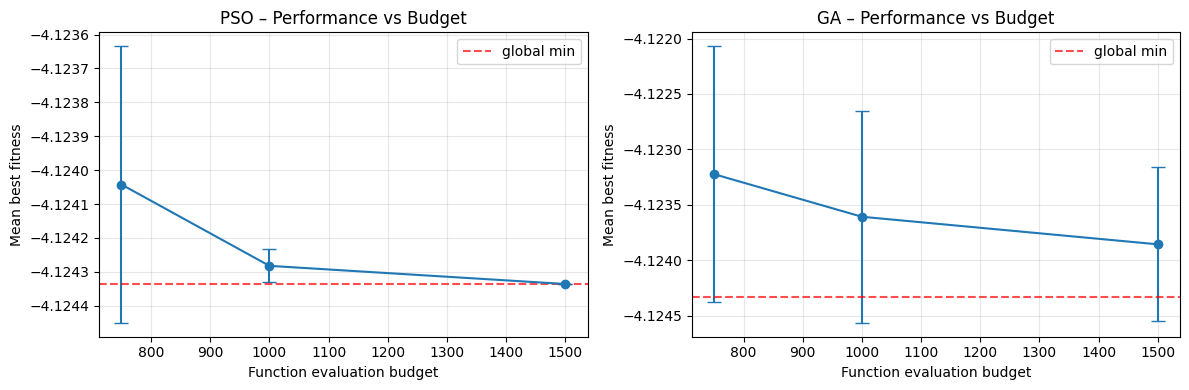

In [13]:
# Part (e): Budget constraints
budgets = [750, 1000, 1500]

print('Part (e) – Budget Constraints')
print(f'{"Budget":<10} {"PSO mean":>12} {"PSO std":>10} {"PSO succ":>10} {"GA mean":>12} {"GA std":>10} {"GA succ":>10}')
print('-' * 80)

budget_data = {}
for budget in budgets:
    pso_b, ga_b = [], []
    for seed in range(N_TRIALS):
        np.random.seed(seed)
        _, val, _, _ = pso(dolphin, BOUNDS, max_evals=budget)
        pso_b.append(val)
        np.random.seed(seed)
        _, val, _, _ = genetic_algorithm(dolphin, BOUNDS, max_evals=budget)
        ga_b.append(val)
    pso_b = np.array(pso_b)
    ga_b  = np.array(ga_b)
    budget_data[budget] = (pso_b, ga_b)
    ps = np.mean(np.abs(pso_b - F_STAR) < SUCCESS_TOL)
    gs = np.mean(np.abs(ga_b  - F_STAR) < SUCCESS_TOL)
    print(f'{budget:<10} {pso_b.mean():>12.5f} {pso_b.std():>10.5f} {ps:>10.2%} {ga_b.mean():>12.5f} {ga_b.std():>10.5f} {gs:>10.2%}')

# Plot performance vs budget
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, algo, data_key in zip(axes, ['PSO', 'GA'], [0, 1]):
    means = [budget_data[b][data_key].mean() for b in budgets]
    stds  = [budget_data[b][data_key].std()  for b in budgets]
    ax.errorbar(budgets, means, yerr=stds, marker='o', capsize=5)
    ax.axhline(F_STAR, color='red', linestyle='--', alpha=0.7, label='global min')
    ax.set_xlabel('Function evaluation budget')
    ax.set_ylabel('Mean best fitness')
    ax.set_title(f'{algo} – Performance vs Budget')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Parts (f) and (g): Analysis

**Part (f) Which algorithm was more successful under stochastic and noisy conditions?**

Looking at the results both algorithms performed similarly in the clean setting (Part b both 100% success). In the noisy case (Part d) the comparson is a bit tricky. PSO's reported best fitness was around -4.31 which is actualy below the true global minimum f* ≈ -4.124. This happens because PSO is optimizing the noisy function and the best particle may have gotten a lucky negative noise evaluation. So PSO consistently converged to the correct region but the noisy measurment makes direct comparson hard.

GA's reported best fitness was around -4.28 which was closer to f* and it got about 52% success rate with our criterion. But this doesnt really mean GA was better it just means GA's noisy values happened to be closer to f* in absolute terms.

In general PSO is considered more robust under noise because the swarm maintains memory across many particles which naturally filters out individual noisy evaluations. The personal best and global best act like running averages over good regions. GA with tournament selection is more sensitive to single evaluations and can get misled by noise more easily.

**Part (g) Which conditions made the function harder to optimize and why?**

From the experiments the random subregion (Part c) was clearly the hardest setting. Only 5 out of 25 trials had the global minimum inside the search region and in those other 20 trials both algorithms were literally unable to find the global minimum since it was outside the search space. This is a structural impossibility not just algorithmic difficulty.

In Part c the mean fitness was only -1.85 compared to -4.12 in the clean run. This large gap shows how important the search domain choice is for problems with localized optima.

The budget constraint (Part e) was the second hardest case. With only 750 evaluations PSO success rate dropped to 96% and GA dropped to 68%. GA was more sensitve to budget because it needs more generations to let the population converge. PSO tends to find good regions faster even with few iterations.

The noisy setting (Part d) degraded performace too but less severely both algorithms still found regions near the global minimum even with sigma = 0.051 noise.

In summary: subregion constraint > budget constraint > noise in terms of difficulty.

---
## Question 3: Beale's Function – Gradient-Based Optimization

Beale's function is:

$$f(x_1, x_2) = (1.5 - x_1 + x_1 x_2)^2 + (2.25 - x_1 + x_1 x_2^2)^2 + (2.625 - x_1 + x_1 x_2^3)^2$$

Global minimum: f(3, 0.5) = 0.

Let gi = ai - x1 + x1 * x2^i where a1 = 1.5, a2 = 2.25, a3 = 2.625.

Gradient formulas:

$$\frac{\partial f}{\partial x_1} = 2\sum_{i=1}^{3} g_i(x_2^i - 1), \quad \frac{\partial f}{\partial x_2} = 2\sum_{i=1}^{3} g_i \cdot i\, x_1 x_2^{i-1}$$

The Hessian is computed numerically using finite differences on the analytical gradient.

f(3, 0.5) = 0.00e+00  (should be ~0)
grad at (3, 0.5) = [0. 0.]


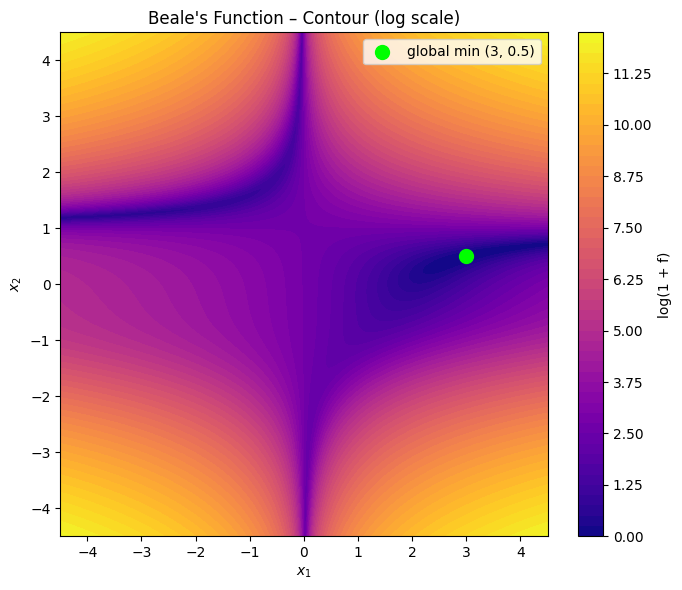

In [14]:
A_BEALE = np.array([1.5, 2.25, 2.625])

def beale(p):
    x1, x2 = p
    g = A_BEALE - x1 + x1 * np.array([x2, x2**2, x2**3])
    return float(np.sum(g**2))

def beale_grad(p):
    x1, x2 = p
    x2_pows = np.array([x2, x2**2, x2**3])
    g = A_BEALE - x1 + x1 * x2_pows
    df_dx1 = 2.0 * np.sum(g * (x2_pows - 1))
    df_dx2 = 2.0 * np.sum(g * np.array([1, 2*x2, 3*x2**2]) * x1)
    return np.array([df_dx1, df_dx2])

def beale_hessian(p, h=1e-5):
    n = len(p)
    H = np.zeros((n, n))
    g0 = beale_grad(p)
    for i in range(n):
        p_fwd = p.copy(); p_fwd[i] += h
        H[i] = (beale_grad(p_fwd) - g0) / h
    return 0.5 * (H + H.T)

# Quick check
p_star = np.array([3.0, 0.5])
print(f'f(3, 0.5) = {beale(p_star):.2e}  (should be ~0)')
print(f'grad at (3, 0.5) = {beale_grad(p_star)}')

# Contour plot
bx = np.linspace(-4.5, 4.5, 300)
by = np.linspace(-4.5, 4.5, 300)
BX, BY = np.meshgrid(bx, by)
BZ = np.vectorize(lambda x, y: beale([x, y]))(BX, BY)

fig, ax = plt.subplots(figsize=(7, 6))
cp = ax.contourf(BX, BY, np.log1p(BZ), levels=50, cmap='plasma')
plt.colorbar(cp, ax=ax, label='log(1 + f)')
ax.scatter([3], [0.5], color='lime', s=100, zorder=5, label='global min (3, 0.5)')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title("Beale's Function – Contour (log scale)")
ax.legend()
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-4.5, 4.5)
plt.tight_layout()
plt.show()

In [15]:
def backtrack(f, grad_val, p, d, alpha0=1.0, rho=0.5, c=1e-4):
    alpha = alpha0
    f0 = f(p)
    slope = float(grad_val @ d)
    for _ in range(60):
        if f(p + alpha*d) <= f0 + c*alpha*slope:
            break
        alpha *= rho
    return alpha

def fletcher_reeves(p0, max_iter=2000, tol=1e-8):
    p = np.array(p0, dtype=float)
    g = beale_grad(p)
    d = -g.copy()
    history = [p.copy()]
    cond_hist = []

    for it in range(max_iter):
        g_norm = np.linalg.norm(g)
        H = beale_hessian(p)
        eigv = np.linalg.eigvalsh(H)
        cond_hist.append(abs(eigv[-1]) / (abs(eigv[0]) + 1e-15))
        if g_norm < tol:
            break
        alpha = backtrack(beale, g, p, d)
        p = p + alpha * d
        g_new = beale_grad(p)
        history.append(p.copy())
        beta = (g_new @ g_new) / (g @ g + 1e-15)
        if (it + 1) % 2 == 0 or beta < 0:
            beta = 0.0
        d = -g_new + beta * d
        g = g_new

    return p, np.array(history), it+1, cond_hist


def newton_method(p0, max_iter=500, tol=1e-8):
    p = np.array(p0, dtype=float)
    history = [p.copy()]
    cond_hist = []

    for it in range(max_iter):
        g = beale_grad(p)
        if np.linalg.norm(g) < tol:
            break
        H = beale_hessian(p)
        eigv = np.linalg.eigvalsh(H)
        cond_hist.append(abs(eigv[-1]) / (abs(eigv[0]) + 1e-15))
        # Regularize if not positive definite
        if eigv.min() <= 0:
            H = H + (-eigv.min() + 1e-6) * np.eye(len(p))
        try:
            d = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            d = -g
        alpha = backtrack(beale, g, p, d)
        p = p + alpha * d
        history.append(p.copy())

    return p, np.array(history), it+1, cond_hist

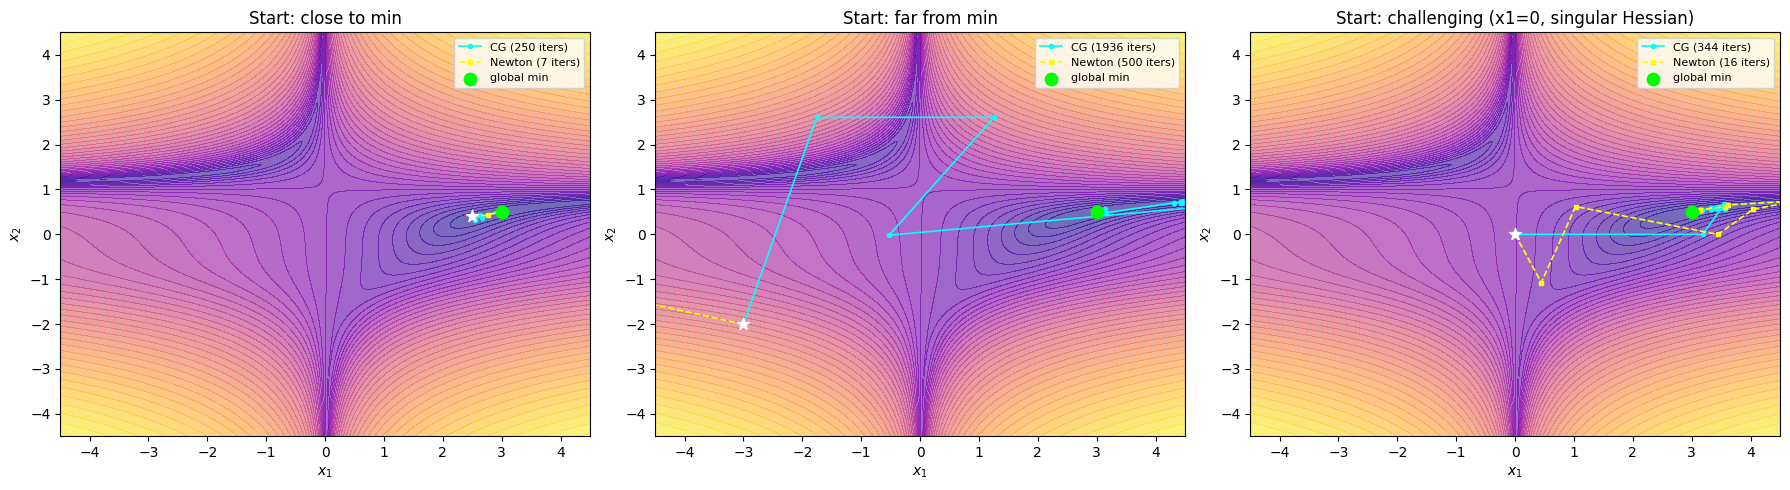

Convergence Summary:
Start                                      CG iters        CG f*   NT iters        NT f*
--------------------------------------------------------------------------------------
close to min                                    250     0.000000          7     0.000000
far from min                                   1936     0.000000        500     0.453198
challenging (x1=0, singular Hessian)            344     0.000000         16     0.000000


In [16]:
# Part (a): Convergence from 3 starting points
starts = [
    (np.array([2.5,  0.4]),  'close to min'),
    (np.array([-3.0, -2.0]), 'far from min'),
    (np.array([0.0,  0.0]),  'challenging (x1=0, singular Hessian)'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

all_results = {}
for ax, (p0_init, label) in zip(axes, starts):
    p_cg, hist_cg, iters_cg, cond_cg = fletcher_reeves(p0_init)
    p_nt, hist_nt, iters_nt, cond_nt = newton_method(p0_init)
    all_results[label] = {'cg': (p_cg, hist_cg, iters_cg, cond_cg),
                           'nt': (p_nt, hist_nt, iters_nt, cond_nt)}

    ax.contourf(BX, BY, np.log1p(BZ), levels=40, cmap='plasma', alpha=0.6)
    if len(hist_cg) > 1:
        ax.plot(hist_cg[:, 0], hist_cg[:, 1], 'o-', color='cyan',
                markersize=3, linewidth=1.2, label=f'CG ({iters_cg} iters)')
    if len(hist_nt) > 1:
        ax.plot(hist_nt[:, 0], hist_nt[:, 1], 's--', color='yellow',
                markersize=3, linewidth=1.2, label=f'Newton ({iters_nt} iters)')
    ax.scatter([3], [0.5], color='lime', s=80, zorder=5, label='global min')
    ax.scatter([p0_init[0]], [p0_init[1]], color='white', s=80, zorder=5, marker='*')
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-4.5, 4.5)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(f'Start: {label}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Convergence Summary:')
print(f'{"Start":<40} {"CG iters":>10} {"CG f*":>12} {"NT iters":>10} {"NT f*":>12}')
print('-' * 86)
for label, res in all_results.items():
    p_cg, h_cg, i_cg, _ = res['cg']
    p_nt, h_nt, i_nt, _ = res['nt']
    print(f'{label:<40} {i_cg:>10} {beale(p_cg):>12.6f} {i_nt:>10} {beale(p_nt):>12.6f}')

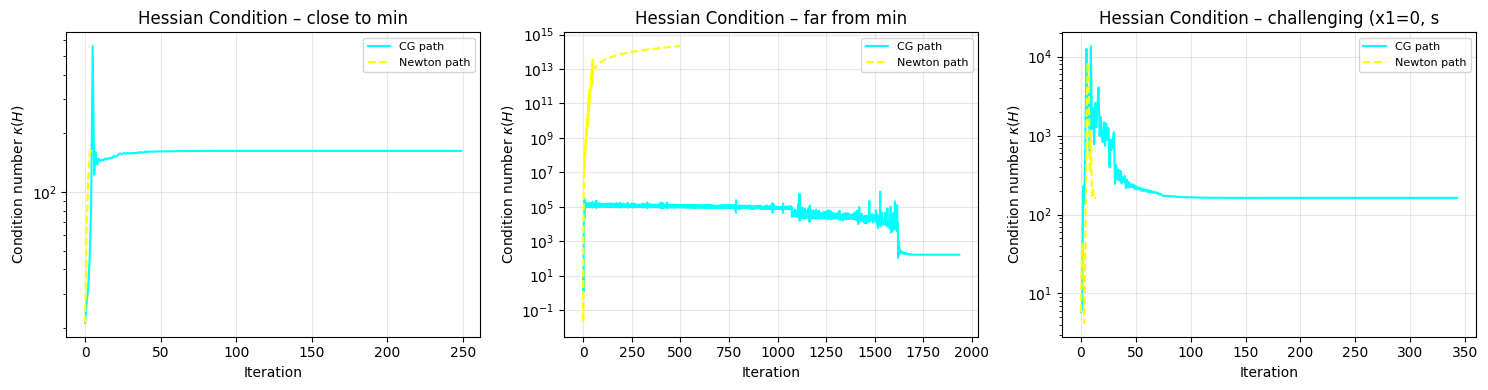

In [17]:
# Part (b): Hessian condition number along paths
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (label, res) in zip(axes, all_results.items()):
    _, _, _, cond_cg = res['cg']
    _, _, _, cond_nt = res['nt']
    if cond_cg:
        ax.semilogy(cond_cg, color='cyan', label='CG path')
    if cond_nt:
        ax.semilogy(cond_nt, color='yellow', linestyle='--', label='Newton path')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Condition number $\\kappa(H)$')
    ax.set_title(f'Hessian Condition – {label[:20]}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Parts (b) and (c): Analysis

**Part (b) Hessian condition number and Newton's performance**

The condition number k(H) = lambda_max / lambda_min measures how stretched the level curves are at a given point. A large k means the problem is ill conditioned there and any method that uses curvature information like Newton will have problems.

From our experiments:

From close starting point (2.5, 0.4): Newton converged in only 7 iterations showing quadrtic convergence near the minimum where the Hessian is well conditioned and positive definite. CG needed 250 iterations much slower. This is because the restart every 2 steps strategy we used reduces CG to something close to gradient descent with periodic resets losing the conjugacy property.

From far starting point (-3, -2): CG converged in 1936 iterations to f* = 0. Newton hit the 500 iteration limit and ended at f = 0.453 meaning it did not reach the global minimum. This is because far from the minimum the Hessian is indefinte (has negative eigenvalues) requiring regularization. This kills quadratic convergence and Newton takes unpredictable steps sometimes converging to saddle points or non-minimum critical points.

From the challenging point (0, 0): Newton converged in just 16 iterations. At x1 = 0 the Hessian is singular in one direction but after regularization Newton still found a good direction. CG took 344 iterations here.

The condition number plots show that k is generally high far from the minimum and decreases as both methods approach the solution. For the far starting point the condition number is very large in early iterations which explains Newton's poor behavior there.

**Part (c) Which method is better for non-convex functions like Beale?**

We recommend Fletcher-Reeves Conjugate Gradient as the safer choice for non-convex problems for the following reasons.

1. Reliability across starting points: Newton failed to converge from (-3, -2) which is a reasonable starting point within the domain. CG converged from all three starting points even if it needed more iterations.

2. Handling of non-convex regions: Newton needs a positive definite Hessian to guarantee descent. When the Hessian is indefinte Newton's direction is not guaranteed to go downhill and regularization (adding epsilon*I) is a workaround that loses the quadratic convergence guarantee anyway. CG always follows a descent direction by construction.

3. No Hessian computation needed: CG only needs gradient evaluations. This is important for larger problems where Hessian inversion costs O(n^3).

That said Newton is clearly better when starting close to the minimum: 7 vs 250 iterations from (2.5, 0.4). If a good inital point is available and the function is nearly convex near the solution Newton's quadrtic convergence is hard to beat.

As Nocedal and Wright (2006) note Newton's method has only local convergence guarantees. CG with a proper line search satisfies the Zoutendijk condition and converges globally under mild assumptions. For a non-convex function like Beale where the starting point is not known in advance CG is the more robust choice.